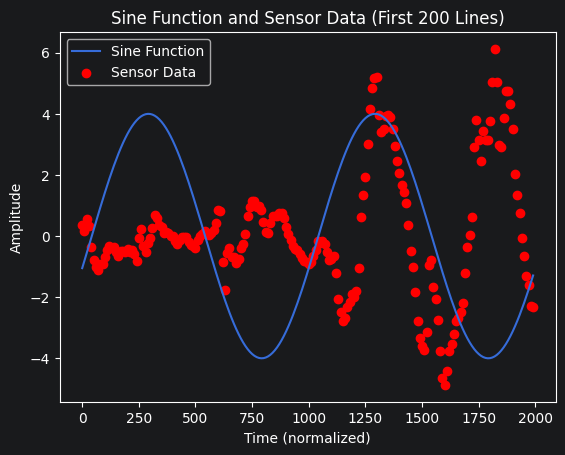

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import csv

# Define sine function with variable parameters
def sine_function(t, amplitude, frequency, phase, displacement):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase) + displacement

# Read data from CSV file (only first 200 lines)
times = []
accel_abs = []
with open('sensordata.csv', 'r') as file:
    csv_reader = csv.reader(file, delimiter=';')
    next(csv_reader)  # Skip header row
    for i, row in enumerate(csv_reader):
        if i >= 200:
            break
        times.append(float(row[0].replace(',', '.')))
        accel_abs.append(float(row[4].replace(',', '.')) - 9.81)

# Normalize time values
times = np.array(times) - times[0]
accel_abs = accel_abs

# Set sine function parameters
amplitude = 4  # Example amplitude
frequency = 0.001  # Example frequency
phase = 50  # Example phase
displacement = 0

# Generate y values for the sine function using normalized time values
y_sine = sine_function(times, amplitude, frequency, phase, displacement)

# Plot sine function and sensor data points
plt.plot(times, y_sine, label='Sine Function')
plt.scatter(times, accel_abs, color='red', label='Sensor Data')

plt.xlabel('Time (normalized)')
plt.ylabel('Amplitude')
plt.title('Sine Function and Sensor Data (First 200 Lines)')
plt.legend()
plt.show()


Best parameters found:
Amplitude: 3.2731066075407838
Frequency: 2.3980469459417453
Phase: -1.0888735276286428


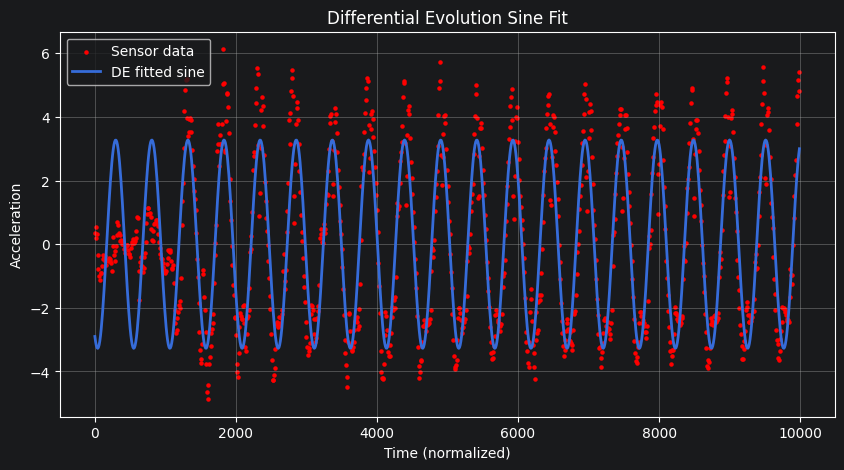

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.optimize import differential_evolution

# ----------------------------
# SINE MODEL
# f(t) = A * sin(2π f t + phase)
# ----------------------------
def sine_function(t, amplitude, frequency, phase, displacement=0):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase) + displacement


# ----------------------------
# LOAD SENSOR DATA
# ----------------------------
times = []
accel_abs = []

with open('sensordata.csv', 'r') as file:
    csv_reader = csv.reader(file, delimiter=';')
    next(csv_reader)  # skip header

    for i, row in enumerate(csv_reader):
        if i >= 1000:   # only first 1000 samples
            break
        times.append(float(row[0].replace(',', '.')))
        accel_abs.append(float(row[4].replace(',', '.')) - 9.81)

times = np.array(times)
accel_abs = np.array(accel_abs)

# normalize time
times = times - times[0]


# ----------------------------
# ERROR FUNCTION (what DE minimizes)
# ----------------------------
def error(params):
    A, f, phi = params
    prediction = sine_function(times, A, f, phi, 0)
    return np.sum((prediction - accel_abs) ** 2)


# ----------------------------
# PARAMETER BOUNDS
# (VERY IMPORTANT for DE performance)
# ----------------------------
bounds = [
    (0, 100),         # amplitude
    (0, 5),          # frequency (Hz)
    (-2*np.pi, 2*np.pi)  # phase
]


# ----------------------------
# RUN DIFFERENTIAL EVOLUTION
# ----------------------------
result = differential_evolution(
    error,
    bounds,
    popsize=150,
    mutation=0.9,
    recombination=0.4,
    seed=42
)

# best parameters
A_opt, f_opt, phi_opt = result.x

print("Best parameters found:")
print("Amplitude:", A_opt)
print("Frequency:", f_opt)
print("Phase:", phi_opt)


# ----------------------------
# BUILD FITTED CURVE
# ----------------------------
y_fit = sine_function(times, A_opt, f_opt, phi_opt, 0)


# ----------------------------
# PLOT RESULTS
# ----------------------------
plt.figure(figsize=(10, 5))
plt.scatter(times, accel_abs, color='red', s=5, label='Sensor data')
plt.plot(times, y_fit, label='DE fitted sine', linewidth=2)

plt.xlabel('Time (normalized)')
plt.ylabel('Acceleration')
plt.title('Differential Evolution Sine Fit')
plt.legend()
plt.grid()
plt.show()

Best parameters found:
  A     = 0.02176 m
  omega = 12.2707 rad/s
  f     = 1.9529 Hz
  rho   = 1.0932 rad
  A*w^2 = 3.2768 m/s²  (acceleration amplitude)

DE Configuration:
  Variant:         best1bin
  Population size: 250 parameters)
  F (mutation):    0.5
  Cr (crossover):  0.4


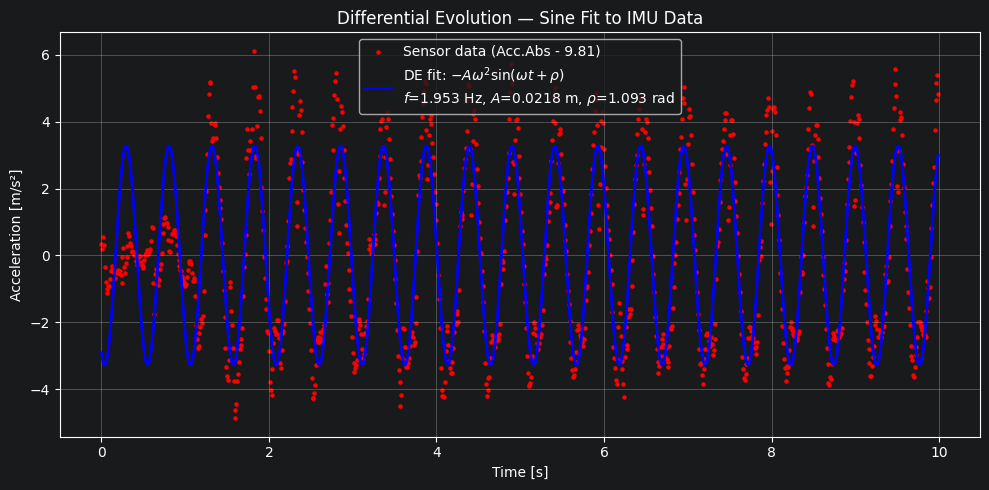

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.optimize import differential_evolution


# ----------------------------
# SINE MODEL  (assignment model)
# f(t) = -A * omega^2 * sin(omega*t + rho)
# (second derivative of displacement -> oscillates around 0)
# ----------------------------
def sine_model(t, A, omega, rho):
    return -A * omega**2 * np.sin(omega * t + rho)


# ----------------------------
# LOAD SENSOR DATA
# Subtract 9.81 so the signal oscillates around 0 (matching the model)
# Timestamps: step=10 ms -> divide by 1000 for seconds
# ----------------------------
times = []
accel_abs = []

with open('sensordata.csv', 'r') as file:
    csv_reader = csv.reader(file, delimiter=';')
    next(csv_reader)  # skip header

    for i, row in enumerate(csv_reader):
        if i >= 1000:   # only first 1000 samples
            break
        times.append(float(row[0].replace(',', '.')))
        accel_abs.append(float(row[4].replace(',', '.')) - 9.81)  # remove gravity

times = np.array(times)
accel_abs = np.array(accel_abs)

# Convert timestamps to seconds (step=10 ms -> 100 Hz)
times = (times - times[0]) / 1000.0


# ----------------------------
# ERROR FUNCTION (what DE minimizes)
# ----------------------------
def error(params):
    A, omega, rho = params
    prediction = sine_model(times, A, omega, rho)
    return np.sum((prediction - accel_abs) ** 2)


# ----------------------------
# PARAMETER BOUNDS
# ----------------------------
bounds = [
    (0.001, 1.0),               # A      displacement amplitude [m]
    (2*np.pi*0.5, 2*np.pi*5),   # omega  angular freq [rad/s]  (0.5-5 Hz walking range)
    (-2*np.pi, 2*np.pi),        # rho    phase [rad]
]


# ----------------------------
# RUN DIFFERENTIAL EVOLUTION
# ----------------------------
strategy      = 'best1bin'
popsize       = 250
mutation      = 0.5
recombination = 0.4
seed          = 42

result = differential_evolution(
    error,
    bounds,
    strategy=strategy,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    seed=seed
)

A_opt, omega_opt, rho_opt = result.x
f_opt = omega_opt / (2 * np.pi)   # Hz for readability

print("Best parameters found:")
print(f"  A     = {A_opt:.5f} m")
print(f"  omega = {omega_opt:.4f} rad/s")
print(f"  f     = {f_opt:.4f} Hz")
print(f"  rho   = {rho_opt:.4f} rad")
print(f"  A*w^2 = {A_opt * omega_opt**2:.4f} m/s²  (acceleration amplitude)")

print("\nDE Configuration:")
print(f"  Variant:         {strategy}")
print(f"  Population size: {popsize } parameters)")
print(f"  F (mutation):    {mutation}")
print(f"  Cr (crossover):  {recombination}")


# ----------------------------
# BUILD FITTED CURVE
# ----------------------------
y_fit = sine_model(times, A_opt, omega_opt, rho_opt)


# ----------------------------
# PLOT RESULTS
# ----------------------------
plt.figure(figsize=(10, 5))
plt.scatter(times, accel_abs, color='red', s=5, label='Sensor data (Acc.Abs - 9.81)')
plt.plot(times, y_fit, color='blue', linewidth=2,
         label=f'DE fit: $-A\\omega^2\\sin(\\omega t+\\rho)$\n'
               f'$f$={f_opt:.3f} Hz, $A$={A_opt:.4f} m, $\\rho$={rho_opt:.3f} rad')

plt.xlabel('Time [s]')
plt.ylabel('Acceleration [m/s²]')
plt.title('Differential Evolution — Sine Fit to IMU Data')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('de_sensor_fitting.png', dpi=150)
plt.show()